# Parameter Count, FLOPs, and Inference Time Analysis: DNAformer vs. Compact BiGRU

This notebook performs a module-by-module comparison of:

1. **DNAformer** — the exact architecture from Bar-Lev *et al.* (Nature Mach. Intell., 2024) and the
   public GitHub repository (siamese, 12-layer Transformer, *d_model* = 1024, 4-kernel multi-head conv).
2. **Our Compact BiGRU model** — `ImprovedDNAReconstructionModel` from
   `DNA-GRU-CPL-MultiThreshold.py`, which replaces the Transformer with a 2-layer BiGRU and drops
   the siamese / fusion modules.

For each dataset we report (i) parameter count, (ii) FLOPs per forward pass and (iii) **wall-clock
inference time** (mean ± std over a number of warm-started runs, batch size 1, max cluster size 16).

> **Sequence-length convention** — this is the key correction over the older analysis script.
> In our reference code (`DNA-GRU-CPL-MultiThreshold.py`):
>
> | symbol | meaning |
> |---|---|
> | `LABEL_SEQ_LEN` | length of the **decoder output**; for binned datasets the 12-bp index is *not* part of it (so it is 128, not 140) |
> | `ORIGINAL_SEQ_LEN` | un-deviated length of a noisy read = `LABEL_SEQ_LEN + INDEX_LENGTH` if `filter_index` else `LABEL_SEQ_LEN` |
> | `MAX_READ_LEN`    | input length seen by the network = `ORIGINAL_SEQ_LEN + MAX_DEVIATION + 8` (the +8 is a padding buffer) |
>
> DNAformer's own convention (`train.py`) is slightly different — it stores the *full* label length
> (including the index) and then subtracts the index after `filter_index`. Translating to the same
> dataset, the two conventions yield the same effective input/output lengths per dataset, e.g. for
> *BinnedNanoporeTwoFlowcells*: output 128, input 132 (DNAformer) / 152 (ours, with +8 buffer).
> We use *each model's own native input length* in this notebook so the comparison reflects what
> each model actually consumes.

In [1]:
import math
import time
from collections import OrderedDict
from typing import Dict

import numpy as np
import pandas as pd
import torch, os
import torch.nn as nn
import torch.nn.functional as F
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:    {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.1.2
CUDA available:  True
Using device:    cuda
GPU: NVIDIA GeForce RTX 3080


## 1. Dataset configurations (corrected)

These are taken **verbatim** from `DATASET_CONFIGS` in `DNA-GRU-CPL-MultiThreshold.py`. In particular,
`label_len = 128` for the binned datasets is the *post-index-removal* label length used by the model,
exactly as in the reference code.

In [2]:
# CORRECTED dataset configs — taken verbatim from DNA-GRU-CPL-MultiThreshold.py.
# In our reference code:
#   LABEL_SEQ_LEN = label_len            (this is the OUTPUT length; index already excluded)
#   ORIGINAL_SEQ_LEN = label_len + index_length  if filter_index else label_len
#   MAX_READ_LEN     = ORIGINAL_SEQ_LEN + max_deviation + 8
DATASET_CONFIGS = {
    "Erlich": {
        "label_len": 152, "index_length": 16, "max_deviation": 10,
        "filter_index": False,
        "description": "Erlich et al. (2017) – DNA Fountain, Illumina miSeq",
    },
    "Grass": {
        "label_len": 117, "index_length": 13, "max_deviation": 11,
        "filter_index": False,
        "description": "Grass et al. (2015) – CustomArray, Illumina miSeq",
    },
    "Organick": {
        "label_len": 110, "index_length": 33, "max_deviation": 5,
        "filter_index": False,
        "description": "Organick et al. (2018) – Twist, Illumina NextSeq",
    },
    "Srinivasavaradhan": {
        "label_len": 110, "index_length": 4, "max_deviation": 10,
        "filter_index": False,
        "description": "Srinivasavaradhan et al. – Twist, MinION",
    },
    "BinnedTestIllumina": {
        "label_len": 128, "index_length": 12, "max_deviation": 4,
        "filter_index": True,
        "description": "DNAformer Test Illumina – Twist + miSeq",
    },
    "BinnedNanoporeTwoFlowcells": {
        "label_len": 128, "index_length": 12, "max_deviation": 4,
        "filter_index": True,
        "description": "DNAformer Nanopore Two Flowcells Combined",
    },
}

# Pretty print
print(f"{'Dataset':<28} {'label_len':>9} {'idx_len':>7} {'max_dev':>7} {'filter':>7}")
print("-" * 60)
for k, c in DATASET_CONFIGS.items():
    print(f"{k:<28} {c['label_len']:>9} {c['index_length']:>7} {c['max_deviation']:>7} {str(c['filter_index']):>7}")

Dataset                      label_len idx_len max_dev  filter
------------------------------------------------------------
Erlich                             152      16      10   False
Grass                              117      13      11   False
Organick                           110      33       5   False
Srinivasavaradhan                  110       4      10   False
BinnedTestIllumina                 128      12       4    True
BinnedNanoporeTwoFlowcells         128      12       4    True


## 2. Effective input / output lengths for each model

The two models have different conventions for the input length of a read:

* **Compact BiGRU (ours)** uses `MAX_READ_LEN = ORIGINAL_SEQ_LEN + MAX_DEVIATION + 8`. The +8
  padding buffer was added to be safe for occasional reads slightly longer than `+max_deviation`.
* **DNAformer** uses `noisy_copies_length = label_length + corrupt_max_deviation`
  (and `-= index_length` if `filter_index`), with **no extra buffer**.

For a fair comparison we feed each model with **its own native input length** — so the parameter
counts and FLOPs reflect the actual deployed configuration of each model.

In [3]:
def derive_lengths(cfg):
    """Return a dict with the effective input/output lengths used by each model."""
    label_len   = cfg['label_len']
    idx_len     = cfg['index_length']
    max_dev     = cfg['max_deviation']
    filter_idx  = cfg['filter_index']

    # ---- Compact BiGRU (current reference code) -------------------------------
    # LABEL_SEQ_LEN = label_len  (already post-filter for binned datasets)
    compact_label_seq_len = label_len
    if filter_idx:
        compact_original_seq_len = label_len + idx_len   # ← index is BACK in the read
    else:
        compact_original_seq_len = label_len
    compact_max_read_len = compact_original_seq_len + max_dev + 8

    # ---- DNAformer (paper / GitHub convention) --------------------------------
    # In DNAformer's train.py: label_length stores the FULL label (incl. index);
    # noisy_copies_length = label_length + max_deviation; then subtract index_length
    # if filter_index. The output length seen by the model is label_length - index_length.
    dnaf_label_full = label_len + idx_len if filter_idx else label_len
    dnaf_noisy_copies_length = dnaf_label_full + max_dev
    dnaf_label_length = dnaf_label_full
    if filter_idx:
        dnaf_noisy_copies_length -= idx_len
        dnaf_label_length        -= idx_len

    return {
        "compact_label_seq_len":  compact_label_seq_len,
        "compact_max_read_len":   compact_max_read_len,
        "dnaformer_label_length": dnaf_label_length,
        "dnaformer_noisy_copies_length": dnaf_noisy_copies_length,
    }

print(f"{'Dataset':<28} {'compact L':>10} {'compact R':>10} "
      f"{'dnaf L':>8} {'dnaf R':>8}")
print("-" * 70)
for name, cfg in DATASET_CONFIGS.items():
    L = derive_lengths(cfg)
    print(f"{name:<28} "
          f"{L['compact_label_seq_len']:>10} "
          f"{L['compact_max_read_len']:>10} "
          f"{L['dnaformer_label_length']:>8} "
          f"{L['dnaformer_noisy_copies_length']:>8}")

Dataset                       compact L  compact R   dnaf L   dnaf R
----------------------------------------------------------------------
Erlich                              152        170      152      162
Grass                               117        136      117      128
Organick                            110        123      110      115
Srinivasavaradhan                   110        128      110      120
BinnedTestIllumina                  128        152      128      132
BinnedNanoporeTwoFlowcells          128        152      128      132


## 3. DNAformer architecture (verbatim from the GitHub code)

Hyper-parameters from the paper's supplementary material:

* `n_head = 32`
* `num_layers = 12`
* `d_model = 1024`
* `alignment_filters = 128`
* `dim_feedforward = 2048`
* `output_ch = 4`
* `enc_filters = 4` (one-hot DNA encoding)
* Kernel sizes: {1, 3, 5, 7}
* Siamese architecture (2 branches with shared weights)

In [4]:
# =============================================================================
# DNAFormer building blocks (exact reproduction of the public code)
# =============================================================================

class depthwise_separable_conv_1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernels_per_layer=1, kernel_size=3, stride=1, padding=0):
        super().__init__()
        self.depthwise = nn.Conv1d(in_ch, in_ch * kernels_per_layer, kernel_size=kernel_size,
                                   stride=stride, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv1d(in_ch * kernels_per_layer, out_ch, kernel_size=1)
    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class double_conv1D(nn.Module):
    """(conv → norm → act) × 2"""
    def __init__(self, in_ch, out_ch, seq_len, padding=0, kernel_size=3, stride=1, p_dropout=0):
        super().__init__()
        self.conv = nn.Sequential(
            depthwise_separable_conv_1d(in_ch, out_ch, 1, kernel_size, stride, padding),
            nn.LayerNorm(seq_len, elementwise_affine=True), nn.GELU(), nn.Dropout(p_dropout),
            depthwise_separable_conv_1d(out_ch, out_ch, 1, kernel_size, stride, padding),
            nn.LayerNorm(seq_len, elementwise_affine=True), nn.GELU(), nn.Dropout(p_dropout),
        )
    def forward(self, x):
        return self.conv(x)


class linear_block(nn.Module):
    """Linear → LN → GELU → DO → Linear → LN → GELU → DO → Linear"""
    def __init__(self, input_len, output_len, p_dropout=0):
        super().__init__()
        self.fc_1 = nn.Linear(input_len, output_len)
        self.norm_1 = nn.LayerNorm(output_len, elementwise_affine=True)
        self.act_1 = nn.GELU(); self.dout_1 = nn.Dropout(p_dropout)
        self.fc_2 = nn.Linear(output_len, output_len)
        self.norm_2 = nn.LayerNorm(output_len, elementwise_affine=True)
        self.act_2 = nn.GELU(); self.dout_2 = nn.Dropout(p_dropout)
        self.fc_3 = nn.Linear(output_len, output_len)
    def forward(self, x):
        x = self.dout_1(self.act_1(self.norm_1(self.fc_1(x))))
        x = self.dout_2(self.act_2(self.norm_2(self.fc_2(x))))
        return self.fc_3(x)


class alignement_module(nn.Module):
    """4 parallel double_conv1D branches with kernels {1,3,5,7} + linear_block."""
    def __init__(self, enc_filters, alignment_filters, noisy_copies_length, p_dropout=0):
        super().__init__()
        out_ch = alignment_filters // 4
        self.conv_block_1 = double_conv1D(enc_filters, out_ch, noisy_copies_length, kernel_size=1, p_dropout=p_dropout)
        self.conv_block_2 = double_conv1D(enc_filters, out_ch, noisy_copies_length, kernel_size=3, padding=1, p_dropout=p_dropout)
        self.conv_block_3 = double_conv1D(enc_filters, out_ch, noisy_copies_length, kernel_size=5, padding=2, p_dropout=p_dropout)
        self.conv_block_4 = double_conv1D(enc_filters, out_ch, noisy_copies_length, kernel_size=7, padding=3, p_dropout=p_dropout)
        self.linear_block = linear_block(noisy_copies_length, noisy_copies_length, p_dropout)
    def forward(self, x):
        b, c, e, s = x.shape
        x = x.view(b * c, e, s)
        x = torch.cat([self.conv_block_1(x), self.conv_block_2(x),
                       self.conv_block_3(x), self.conv_block_4(x)], dim=1)
        x = self.linear_block(x)
        return x.view(b, c, -1, s)


class embedding_module(nn.Module):
    """Same structure as alignment, but maps noisy_copies_length → label_length."""
    def __init__(self, alignment_filters, d_model, noisy_copies_length, label_length, p_dropout=0):
        super().__init__()
        out_ch = d_model // 4
        self.conv_block_1 = double_conv1D(alignment_filters, out_ch, noisy_copies_length, kernel_size=1, p_dropout=p_dropout)
        self.conv_block_2 = double_conv1D(alignment_filters, out_ch, noisy_copies_length, kernel_size=3, padding=1, p_dropout=p_dropout)
        self.conv_block_3 = double_conv1D(alignment_filters, out_ch, noisy_copies_length, kernel_size=5, padding=2, p_dropout=p_dropout)
        self.conv_block_4 = double_conv1D(alignment_filters, out_ch, noisy_copies_length, kernel_size=7, padding=3, p_dropout=p_dropout)
        self.linear_block = linear_block(noisy_copies_length, label_length, p_dropout)
    def forward(self, x):
        x = torch.sum(x, dim=1)  # NCI
        x = torch.cat([self.conv_block_1(x), self.conv_block_2(x),
                       self.conv_block_3(x), self.conv_block_4(x)], dim=1)
        return self.linear_block(x)


class output_module(nn.Module):
    """3 × Conv1×1: d_model → d_model → d_model → output_ch (4)."""
    def __init__(self, d_model, output_ch):
        super().__init__()
        self.conv_1 = nn.Conv1d(d_model, d_model, 1)
        self.conv_2 = nn.Conv1d(d_model, d_model, 1)
        self.conv_3 = nn.Conv1d(d_model, output_ch, 1)
    def forward(self, x):
        return self.conv_3(self.conv_2(self.conv_1(x)))


class fusion_module(nn.Module):
    """2 learnable fusion vectors (left, right) + 3 × Conv1×1."""
    def __init__(self, output_ch, label_length):
        super().__init__()
        self.pred_fusion_left  = nn.Parameter(torch.ones(label_length))
        self.pred_fusion_right = nn.Parameter(torch.ones(label_length))
        self.conv_1 = nn.Conv1d(output_ch, output_ch, 1)
        self.conv_2 = nn.Conv1d(output_ch, output_ch, 1)
        self.conv_3 = nn.Conv1d(output_ch, output_ch, 1)
    def forward(self, x):
        x_left  = x[: x.shape[0] // 2]
        x_right = torch.flip(x[x.shape[0] // 2 :], dims=[-1])
        x = (x_left * self.pred_fusion_left + x_right * self.pred_fusion_right) / 2
        x = self.conv_3(self.conv_2(self.conv_1(x)))
        return x, x_left, x_right


class DNAFormer(nn.Module):
    """Siamese DNAFormer (shared weights between left & right branches)."""
    def __init__(self, enc_filters, alignment_filters, d_model, n_head,
                 num_layers, dim_feedforward, output_ch,
                 noisy_copies_length, label_length, p_dropout=0):
        super().__init__()
        self.alignement = alignement_module(enc_filters, alignment_filters,
                                            noisy_copies_length, p_dropout)
        self.embedding  = embedding_module(alignment_filters, d_model,
                                           noisy_copies_length, label_length, p_dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_head, dim_feedforward=dim_feedforward,
            dropout=p_dropout, activation='gelu', batch_first=False)
        self.encoder       = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_module = output_module(d_model, output_ch)
        self.fusion        = fusion_module(output_ch, label_length)

    def forward(self, x):
        # x: (2*B, cluster, enc_filters, noisy_copies_length) — siamese pair stacked along batch dim
        x = self.alignement(x)
        x = self.embedding(x)
        x = x.permute(2, 0, 1)
        x = self.encoder(x)
        x = x.permute(1, 2, 0)
        x = self.output_module(x)
        x, x_left, x_right = self.fusion(x)
        return {'pred': x, 'pred_left': x_left, 'pred_right': x_right}

## 4. Compact BiGRU model (verbatim from `DNA-GRU-CPL-MultiThreshold.py`)

* `embed_dim = 300`
* `alignment_filters = 128`
* `embedding_filters = 500`
* `gru_hidden = 300`, `gru_layers = 2` (bidirectional)
* Kernel sizes: {1, 3, 5}
* No siamese, no fusion, single linear output layer.

In [5]:
# =============================================================================
# Compact BiGRU — copied verbatim from DNA-GRU-CPL-MultiThreshold.py
# =============================================================================

class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0):
        super().__init__()
        self.depthwise = nn.Conv1d(in_channels, in_channels, kernel_size=kernel_size,
                                   padding=padding, groups=in_channels)
        self.pointwise = nn.Conv1d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class MultiKernelConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, seq_len, dropout=0.1):
        super().__init__()
        c1 = out_channels // 3
        c2 = out_channels // 3
        c3 = out_channels - c1 - c2
        self.conv1 = DepthwiseSeparableConv1d(in_channels, c1, kernel_size=1)
        self.conv3 = DepthwiseSeparableConv1d(in_channels, c2, kernel_size=3, padding=1)
        self.conv5 = DepthwiseSeparableConv1d(in_channels, c3, kernel_size=5, padding=2)
        self.norm1 = nn.LayerNorm([c1, seq_len])
        self.norm2 = nn.LayerNorm([c2, seq_len])
        self.norm3 = nn.LayerNorm([c3, seq_len])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x1 = F.gelu(self.norm1(self.conv1(x)))
        x2 = F.gelu(self.norm2(self.conv3(x)))
        x3 = F.gelu(self.norm3(self.conv5(x)))
        return self.dropout(torch.cat([x1, x2, x3], dim=1))


class AlignmentModule(nn.Module):
    def __init__(self, embed_dim, out_channels, seq_len, dropout=0.1):
        super().__init__()
        self.conv_block1 = MultiKernelConvBlock(embed_dim, out_channels, seq_len, dropout)
        self.conv_block2 = MultiKernelConvBlock(out_channels, out_channels, seq_len, dropout)
    def forward(self, x):
        b, c, e, s = x.shape
        x = x.view(b * c, e, s)
        x = self.conv_block2(self.conv_block1(x))
        return x.view(b, c, -1, s)


class EmbeddingModule(nn.Module):
    def __init__(self, in_channels, out_channels, in_len, out_len, dropout=0.1):
        super().__init__()
        self.conv_block = MultiKernelConvBlock(in_channels, out_channels, in_len, dropout)
        self.linear = nn.Linear(in_len, out_len)
    def forward(self, x):
        x = self.conv_block(x)
        b, c, s = x.shape
        x = x.reshape(b * c, s)
        x = self.linear(x)
        return x.reshape(b, c, -1)


class ImprovedDNAReconstructionModel(nn.Module):
    def __init__(self, vocab_size, label_seq_len, max_read_len, padding_idx,
                 embed_dim=300, alignment_filters=128, embedding_filters=500,
                 gru_hidden=300, gru_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.alignment = AlignmentModule(embed_dim, alignment_filters, max_read_len, dropout)
        self.embedding_module = EmbeddingModule(alignment_filters, embedding_filters,
                                                max_read_len, label_seq_len, dropout)
        self.gru = nn.GRU(embedding_filters, gru_hidden, num_layers=gru_layers,
                         batch_first=True, bidirectional=True,
                         dropout=dropout if gru_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(gru_hidden * 2, vocab_size)
    def forward(self, cluster_batch):
        emb = self.embedding(cluster_batch).permute(0, 1, 3, 2)
        aligned = self.alignment(emb)
        nci = torch.sum(aligned, dim=1)
        feats = self.embedding_module(nci).permute(0, 2, 1)
        gru_out, _ = self.gru(feats)
        return self.fc_out(self.dropout(gru_out))

## 5. Parameter and FLOP counters

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_parameters_by_module(model):
    out = OrderedDict()
    for name, mod in model.named_children():
        out[name] = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    out['TOTAL'] = count_parameters(model)
    return out

def fmt(n):
    if n >= 1e9: return f"{n/1e9:.2f}B"
    if n >= 1e6: return f"{n/1e6:.2f}M"
    if n >= 1e3: return f"{n/1e3:.2f}K"
    return str(n)

In [7]:
# -----------------------------------------------------------------------------
# Analytical FLOP counters (forward pass, MACs × 2)
# -----------------------------------------------------------------------------

def count_dnaformer_flops(enc_filters, alignment_filters, d_model, n_head,
                          num_layers, dim_feedforward, output_ch,
                          noisy_copies_length, label_length,
                          batch_size=1, max_cluster_size=16, siamese=True):
    """FLOPs for DNAformer (siamese: doubles per-read FLOPs by processing the flipped copy too)."""
    flops = OrderedDict()
    # In siamese mode the entire pipeline runs on the original AND the reverse-flipped reads.
    # We model that by a multiplicative factor on the per-read pipeline (alignment + embedding +
    # encoder + output) since the fusion module merges the two halves at the very end.
    siamese_factor = 2 if siamese else 1
    num_reads = batch_size * max_cluster_size

    def ds_conv(in_ch, out_ch, k, L):
        depthwise = in_ch * k * L
        pointwise = in_ch * out_ch * L
        return 2 * (depthwise + pointwise)

    def double_conv(in_ch, out_ch, k, L):
        return (ds_conv(in_ch, out_ch, k, L) + ds_conv(out_ch, out_ch, k, L)
                + 2 * 5 * out_ch * L      # 2× LayerNorm
                + 2 * 8 * out_ch * L)     # 2× GELU

    def linear_blk(in_len, out_len, channels):
        fc1 = 2 * channels * in_len * out_len
        fc2 = 2 * channels * out_len * out_len
        fc3 = 2 * channels * out_len * out_len
        return fc1 + fc2 + fc3 + 2*5*channels*out_len + 2*8*channels*out_len

    # --- Alignment (per-read) ---
    a_oc = alignment_filters // 4
    align_convs = sum(double_conv(enc_filters, a_oc, k, noisy_copies_length)
                      for k in (1, 3, 5, 7)) * num_reads * siamese_factor
    align_lin   = linear_blk(noisy_copies_length, noisy_copies_length, alignment_filters)                   * num_reads * siamese_factor
    flops['Alignment_Module_Total'] = align_convs + align_lin

    # --- Embedding (NCI + multi-kernel + linear: noisy → label) ---
    e_oc = d_model // 4
    emb_convs = sum(double_conv(alignment_filters, e_oc, k, noisy_copies_length)
                    for k in (1, 3, 5, 7)) * batch_size * siamese_factor
    emb_lin   = linear_blk(noisy_copies_length, label_length, d_model) * batch_size * siamese_factor
    flops['Embedding_Module_Total'] = emb_convs + emb_lin

    # --- Transformer encoder ---
    seq = label_length
    qkv      = 3 * 2 * batch_size * seq * d_model * d_model
    a_scores = 2 * batch_size * n_head * seq * seq * (d_model // n_head)
    softmax  = 5 * batch_size * n_head * seq * seq
    a_out    = 2 * batch_size * n_head * seq * (d_model // n_head) * seq
    o_proj   = 2 * batch_size * seq * d_model * d_model
    attn     = qkv + a_scores + softmax + a_out + o_proj
    ffn      = 2 * 2 * batch_size * seq * d_model * dim_feedforward
    lns      = 2 * 5 * batch_size * seq * d_model
    per_layer = attn + ffn + lns
    flops['Transformer_Total'] = per_layer * num_layers * siamese_factor

    # --- Output module (3 × 1×1 conv) ---
    out_total = (2 * batch_size * d_model * d_model * label_length            # conv1
                 + 2 * batch_size * d_model * d_model * label_length          # conv2
                 + 2 * batch_size * d_model * output_ch * label_length)       # conv3
    flops['Output_Module_Total'] = out_total * siamese_factor

    # --- Fusion (after siamese halves are merged: only one branch worth of conv) ---
    fusion = (3 * 2 * batch_size * output_ch * output_ch * label_length
              + batch_size * output_ch * label_length * 4)
    flops['Fusion_Module_Total'] = fusion

    flops['GRAND_TOTAL'] = (flops['Alignment_Module_Total'] + flops['Embedding_Module_Total']
                             + flops['Transformer_Total'] + flops['Output_Module_Total']
                             + flops['Fusion_Module_Total'])
    return flops


def count_compact_flops(vocab_size, embed_dim, alignment_filters, embedding_filters,
                        gru_hidden, gru_layers, max_read_len, label_seq_len,
                        batch_size=1, max_cluster_size=16):
    flops = OrderedDict()
    num_reads = batch_size * max_cluster_size

    def ds_conv(in_ch, out_ch, k, L):
        return 2 * (in_ch * k * L + in_ch * out_ch * L)

    def mk_block(in_ch, out_ch, L):
        c1 = out_ch // 3; c2 = out_ch // 3; c3 = out_ch - c1 - c2
        return (ds_conv(in_ch, c1, 1, L) + ds_conv(in_ch, c2, 3, L) + ds_conv(in_ch, c3, 5, L)
                + 5 * (c1 + c2 + c3) * L + 8 * out_ch * L)

    flops['Embedding_Layer'] = 0
    flops['Alignment_Module_Total'] = (
        mk_block(embed_dim, alignment_filters, max_read_len) +
        mk_block(alignment_filters, alignment_filters, max_read_len)
    ) * num_reads
    flops['NCI'] = batch_size * max_cluster_size * alignment_filters * max_read_len
    flops['Embedding_Module_Total'] = (
        mk_block(alignment_filters, embedding_filters, max_read_len) * batch_size
        + 2 * batch_size * embedding_filters * max_read_len * label_seq_len
    )
    gru_flops = 0
    for layer in range(gru_layers):
        in_size = embedding_filters if layer == 0 else 2 * gru_hidden
        per_t = 3 * 2 * (in_size * gru_hidden + gru_hidden * gru_hidden) + 30 * gru_hidden
        per_t *= 2  # bidirectional
        gru_flops += batch_size * label_seq_len * per_t
    flops['BiGRU_Total'] = gru_flops
    flops['Output_Linear'] = 2 * batch_size * label_seq_len * (2 * gru_hidden) * vocab_size
    flops['GRAND_TOTAL'] = (flops['Alignment_Module_Total'] + flops['NCI']
                             + flops['Embedding_Module_Total']
                             + flops['BiGRU_Total'] + flops['Output_Linear'])
    return flops

## 6. Wall-clock inference timing

For each dataset and each model we measure the **forward-pass latency** with:

* `batch_size = 1`
* `max_cluster_size = 16`
* `n_warmup = 5` warm-up iterations (discarded)
* `n_repeat = 30` timed iterations
* CUDA events when on GPU (`torch.cuda.synchronize` + `cuda.Event`), `time.perf_counter` on CPU

We report **mean ± std (ms)** and **throughput (clusters / s)**. Because the comparison is
per-cluster, dividing by 1 — these two numbers carry the same information; we keep both for
convenience.

In [8]:
@torch.no_grad()
def time_module(model, input_factory, n_warmup=5, n_repeat=30, device="cpu"):
    """Time `model(input)` on `device`. `input_factory()` returns a fresh input tensor each call."""
    model.eval()
    # Warm-up
    for _ in range(n_warmup):
        x = input_factory()
        _ = model(x)
    if device == "cuda":
        torch.cuda.synchronize()
        starts = [torch.cuda.Event(enable_timing=True) for _ in range(n_repeat)]
        ends   = [torch.cuda.Event(enable_timing=True) for _ in range(n_repeat)]
        for i in range(n_repeat):
            x = input_factory()
            starts[i].record()
            _ = model(x)
            ends[i].record()
        torch.cuda.synchronize()
        times_ms = np.array([starts[i].elapsed_time(ends[i]) for i in range(n_repeat)])
    else:
        times_ms = np.empty(n_repeat)
        for i in range(n_repeat):
            x = input_factory()
            t0 = time.perf_counter()
            _ = model(x)
            times_ms[i] = (time.perf_counter() - t0) * 1000.0
    return times_ms

## 7. Run the full analysis

For each dataset we instantiate both models with the **correct** lengths, count parameters and FLOPs,
and time a single forward pass.

In [9]:
# ----------------------------- Hyper-parameters ------------------------------
DNAFORMER_CONFIG = {
    'enc_filters': 4, 'alignment_filters': 128, 'd_model': 1024,
    'n_head': 32, 'num_layers': 12, 'dim_feedforward': 2048,
    'output_ch': 4, 'p_dropout': 0,
}

COMPACT_CONFIG = {
    'vocab_size': 5, 'embed_dim': 300, 'alignment_filters': 128,
    'embedding_filters': 500, 'gru_hidden': 300, 'gru_layers': 2,
    'dropout': 0.1, 'padding_idx': 0,
}

MAX_CLUSTER_SIZE = 16
BATCH_SIZE       = 1
N_WARMUP         = 5
N_REPEAT         = 30

# Two switches you may want to flip:
#   (a) RUN_DNAFORMER = False if a 100M-parameter Transformer doesn't fit on your GPU.
#       In that case parameters/FLOPs are still computed analytically, but timing is skipped.
#   (b) DNAFORMER_SIAMESE = True replicates the paper exactly. Set to False for an apples-to-apples
#       single-branch comparison.
RUN_DNAFORMER       = True
DNAFORMER_SIAMESE   = True

In [10]:
results = []
detailed = {}

for dataset_name, cfg in DATASET_CONFIGS.items():
    print(f"\n{'='*78}\nDATASET: {dataset_name}\n{'='*78}")
    print(f"  {cfg['description']}")

    L = derive_lengths(cfg)
    cm_lbl, cm_rd  = L['compact_label_seq_len'],  L['compact_max_read_len']
    df_lbl, df_rd  = L['dnaformer_label_length'], L['dnaformer_noisy_copies_length']

    print(f"  Compact   : label_seq_len = {cm_lbl}, max_read_len = {cm_rd}")
    print(f"  DNAformer : label_length  = {df_lbl}, noisy_copies_length = {df_rd}")

    row = {
        'Dataset': dataset_name,
        'Compact_label_len': cm_lbl, 'Compact_input_len': cm_rd,
        'DNAformer_label_len': df_lbl, 'DNAformer_input_len': df_rd,
    }

    # ------------------- DNAformer ------------------------------------------
    print("  --- DNAformer ---")
    dnf = DNAFormer(
        enc_filters       = DNAFORMER_CONFIG['enc_filters'],
        alignment_filters = DNAFORMER_CONFIG['alignment_filters'],
        d_model           = DNAFORMER_CONFIG['d_model'],
        n_head            = DNAFORMER_CONFIG['n_head'],
        num_layers        = DNAFORMER_CONFIG['num_layers'],
        dim_feedforward   = DNAFORMER_CONFIG['dim_feedforward'],
        output_ch         = DNAFORMER_CONFIG['output_ch'],
        noisy_copies_length = df_rd,
        label_length        = df_lbl,
        p_dropout         = DNAFORMER_CONFIG['p_dropout'],
    )
    dnf_params = count_parameters_by_module(dnf)
    dnf_flops  = count_dnaformer_flops(
        enc_filters       = DNAFORMER_CONFIG['enc_filters'],
        alignment_filters = DNAFORMER_CONFIG['alignment_filters'],
        d_model           = DNAFORMER_CONFIG['d_model'],
        n_head            = DNAFORMER_CONFIG['n_head'],
        num_layers        = DNAFORMER_CONFIG['num_layers'],
        dim_feedforward   = DNAFORMER_CONFIG['dim_feedforward'],
        output_ch         = DNAFORMER_CONFIG['output_ch'],
        noisy_copies_length = df_rd, label_length = df_lbl,
        batch_size = BATCH_SIZE, max_cluster_size = MAX_CLUSTER_SIZE,
        siamese = DNAFORMER_SIAMESE,
    )

    row['DNAformer_params']   = dnf_params['TOTAL']
    row['DNAformer_params_M'] = dnf_params['TOTAL'] / 1e6
    row['DNAformer_FLOPs']    = dnf_flops['GRAND_TOTAL']
    row['DNAformer_FLOPs_G']  = dnf_flops['GRAND_TOTAL'] / 1e9

    print(f"     Parameters: {fmt(dnf_params['TOTAL'])}")
    print(f"     FLOPs    : {fmt(dnf_flops['GRAND_TOTAL'])}")

    if RUN_DNAFORMER:
        try:
            dnf = dnf.to(DEVICE)
            # input shape for DNAformer: (siamese ? 2*B : B, max_cluster, enc_filters, noisy_copies_length)
            outer_batch = 2 * BATCH_SIZE if DNAFORMER_SIAMESE else BATCH_SIZE
            shape = (outer_batch, MAX_CLUSTER_SIZE,
                     DNAFORMER_CONFIG['enc_filters'], df_rd)
            def make_inp(shape=shape):
                return torch.randn(*shape, device=DEVICE)
            t = time_module(dnf, make_inp, N_WARMUP, N_REPEAT, DEVICE)
            row['DNAformer_time_ms_mean'] = float(t.mean())
            row['DNAformer_time_ms_std']  = float(t.std())
            print(f"     Latency  : {t.mean():.2f} ± {t.std():.2f} ms")
        except RuntimeError as e:
            print(f"     ⚠️  Skipping DNAformer timing: {e}")
            row['DNAformer_time_ms_mean'] = float('nan')
            row['DNAformer_time_ms_std']  = float('nan')
        finally:
            del dnf
            if DEVICE == "cuda": torch.cuda.empty_cache()
    else:
        row['DNAformer_time_ms_mean'] = float('nan')
        row['DNAformer_time_ms_std']  = float('nan')

    # ------------------- Compact BiGRU --------------------------------------
    print("  --- Compact BiGRU (ours) ---")
    cm = ImprovedDNAReconstructionModel(
        vocab_size       = COMPACT_CONFIG['vocab_size'],
        label_seq_len    = cm_lbl,
        max_read_len     = cm_rd,
        padding_idx      = COMPACT_CONFIG['padding_idx'],
        embed_dim        = COMPACT_CONFIG['embed_dim'],
        alignment_filters= COMPACT_CONFIG['alignment_filters'],
        embedding_filters= COMPACT_CONFIG['embedding_filters'],
        gru_hidden       = COMPACT_CONFIG['gru_hidden'],
        gru_layers       = COMPACT_CONFIG['gru_layers'],
        dropout          = COMPACT_CONFIG['dropout'],
    )
    cm_params = count_parameters_by_module(cm)
    cm_flops  = count_compact_flops(
        vocab_size = COMPACT_CONFIG['vocab_size'],
        embed_dim  = COMPACT_CONFIG['embed_dim'],
        alignment_filters = COMPACT_CONFIG['alignment_filters'],
        embedding_filters = COMPACT_CONFIG['embedding_filters'],
        gru_hidden = COMPACT_CONFIG['gru_hidden'],
        gru_layers = COMPACT_CONFIG['gru_layers'],
        max_read_len = cm_rd, label_seq_len = cm_lbl,
        batch_size = BATCH_SIZE, max_cluster_size = MAX_CLUSTER_SIZE,
    )

    row['Compact_params']   = cm_params['TOTAL']
    row['Compact_params_M'] = cm_params['TOTAL'] / 1e6
    row['Compact_FLOPs']    = cm_flops['GRAND_TOTAL']
    row['Compact_FLOPs_G']  = cm_flops['GRAND_TOTAL'] / 1e9

    print(f"     Parameters: {fmt(cm_params['TOTAL'])}")
    print(f"     FLOPs    : {fmt(cm_flops['GRAND_TOTAL'])}")

    try:
        cm = cm.to(DEVICE)
        shape = (BATCH_SIZE, MAX_CLUSTER_SIZE, cm_rd)
        def make_inp(shape=shape):
            return torch.randint(0, COMPACT_CONFIG['vocab_size'], shape, device=DEVICE)
        t = time_module(cm, make_inp, N_WARMUP, N_REPEAT, DEVICE)
        row['Compact_time_ms_mean'] = float(t.mean())
        row['Compact_time_ms_std']  = float(t.std())
        print(f"     Latency  : {t.mean():.2f} ± {t.std():.2f} ms")
    except RuntimeError as e:
        print(f"     ⚠️  Skipping compact timing: {e}")
        row['Compact_time_ms_mean'] = float('nan')
        row['Compact_time_ms_std']  = float('nan')
    finally:
        del cm
        if DEVICE == "cuda": torch.cuda.empty_cache()

    # ------------------- Reductions -----------------------------------------
    row['Param_Reduction_%'] = (1 - row['Compact_params'] / row['DNAformer_params']) * 100
    row['FLOP_Reduction_%']  = (1 - row['Compact_FLOPs']  / row['DNAformer_FLOPs'])  * 100
    if not (math.isnan(row['DNAformer_time_ms_mean']) or math.isnan(row['Compact_time_ms_mean'])):
        row['Speedup_x'] = row['DNAformer_time_ms_mean'] / row['Compact_time_ms_mean']
    else:
        row['Speedup_x'] = float('nan')

    print(f"  --- Reductions ---")
    print(f"     Parameters:  {row['Param_Reduction_%']:.1f} %")
    print(f"     FLOPs    :  {row['FLOP_Reduction_%']:.1f} %")
    if not math.isnan(row['Speedup_x']):
        print(f"     Speed-up :  {row['Speedup_x']:.2f}x")

    detailed[dataset_name] = {'dnaformer': {'params': dnf_params, 'flops': dnf_flops},
                              'compact':   {'params': cm_params,  'flops': cm_flops}}
    results.append(row)

df_summary = pd.DataFrame(results)
df_summary


DATASET: Erlich
  Erlich et al. (2017) – DNA Fountain, Illumina miSeq
  Compact   : label_seq_len = 152, max_read_len = 170
  DNAformer : label_length  = 152, noisy_copies_length = 162
  --- DNAformer ---


/homes/shubham/anaconda3/envs/pytorchenv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


     Parameters: 103.47M
     FLOPs    : 66.18B
     Latency  : 11.16 ± 0.28 ms
  --- Compact BiGRU (ours) ---
     Parameters: 3.48M
     FLOPs    : 1.31B
     Latency  : 7.50 ± 0.40 ms
  --- Reductions ---
     Parameters:  96.6 %
     FLOPs    :  98.0 %
     Speed-up :  1.49x

DATASET: Grass
  Grass et al. (2015) – CustomArray, Illumina miSeq
  Compact   : label_seq_len = 117, max_read_len = 136
  DNAformer : label_length  = 117, noisy_copies_length = 128
  --- DNAformer ---
     Parameters: 103.41M
     FLOPs    : 50.38B
     Latency  : 10.81 ± 0.43 ms
  --- Compact BiGRU (ours) ---
     Parameters: 3.42M
     FLOPs    : 1.02B
     Latency  : 5.94 ± 0.14 ms
  --- Reductions ---
     Parameters:  96.7 %
     FLOPs    :  98.0 %
     Speed-up :  1.82x

DATASET: Organick
  Organick et al. (2018) – Twist, Illumina NextSeq
  Compact   : label_seq_len = 110, max_read_len = 123
  DNAformer : label_length  = 110, noisy_copies_length = 115
  --- DNAformer ---
     Parameters: 103.39M
     FL

,Dataset,Compact_label_len,Compact_input_len,DNAformer_label_len,DNAformer_input_len,DNAformer_params,DNAformer_params_M,DNAformer_FLOPs,DNAformer_FLOPs_G,DNAformer_time_ms_mean,DNAformer_time_ms_std,Compact_params,Compact_params_M,Compact_FLOPs,Compact_FLOPs_G,Compact_time_ms_mean,Compact_time_ms_std,Param_Reduction_%,FLOP_Reduction_%,Speedup_x
0,Erlich,152,170,152,162,103467602,103.467602,66177008256,66.177008,11.159589,0.277741,3480949,3.480949,1314100840,1.314101,7.504005,0.396423,96.635711,98.014264,1.487151
1,Grass,117,136,117,128,103407903,103.407903,50384206384,50.384206,10.810841,0.433968,3419578,3.419578,1018175472,1.018175,5.943639,0.138677,96.693117,97.979177,1.818892
2,Organick,110,123,110,115,103392352,103.392352,47213677600,47.213678,10.586281,0.128248,3397533,3.397533,945769596,0.945770,5.709180,0.113571,96.713942,97.996831,1.854256
3,Srinivasavaradhan,110,128,110,120,103396622,103.396622,47255784480,47.255784,10.661991,0.222392,3405643,3.405643,956661856,0.956662,5.836942,0.238038,96.706234,97.975567,1.826640
4,BinnedTestIllumina,128,152,128,132,103418588,103.418588,55248697344,55.248697,10.486071,0.110696,3447325,3.447325,1122596704,1.122597,6.363348,0.098826,96.666629,97.968103,1.647886
5,BinnedNanoporeTwoFlowcells,128,152,128,132,103418588,103.418588,55248697344,55.248697,10.677563,0.217133,3447325,3.447325,1122596704,1.122597,6.336854,0.094107,96.666629,97.968103,1.684994


## 8. Summary tables

In [11]:
# Compact display
display_cols = ['Dataset',
                'Compact_label_len', 'Compact_input_len',
                'DNAformer_params_M', 'Compact_params_M',
                'DNAformer_FLOPs_G',  'Compact_FLOPs_G',
                'DNAformer_time_ms_mean', 'Compact_time_ms_mean',
                'Param_Reduction_%', 'FLOP_Reduction_%', 'Speedup_x']
df_show = df_summary[display_cols].copy()
df_show = df_show.round({
    'DNAformer_params_M': 2, 'Compact_params_M': 2,
    'DNAformer_FLOPs_G': 2,  'Compact_FLOPs_G': 4,
    'DNAformer_time_ms_mean': 2, 'Compact_time_ms_mean': 2,
    'Param_Reduction_%': 1, 'FLOP_Reduction_%': 1, 'Speedup_x': 2,
})
print(df_show.to_string(index=False))

                   Dataset  Compact_label_len  Compact_input_len  DNAformer_params_M  Compact_params_M  DNAformer_FLOPs_G  Compact_FLOPs_G  DNAformer_time_ms_mean  Compact_time_ms_mean  Param_Reduction_%  FLOP_Reduction_%  Speedup_x
                    Erlich                152                170              103.47              3.48              66.18           1.3141                   11.16                  7.50               96.6              98.0       1.49
                     Grass                117                136              103.41              3.42              50.38           1.0182                   10.81                  5.94               96.7              98.0       1.82
                  Organick                110                123              103.39              3.40              47.21           0.9458                   10.59                  5.71               96.7              98.0       1.85
         Srinivasavaradhan                110                128    

In [12]:
# Module-by-module DNAformer parameters
print('=' * 100)
print('DNAformer — module-by-module parameters')
print('=' * 100)
mod_p_dnf = {ds: {
    'Alignment'  : detailed[ds]['dnaformer']['params'].get('alignement', 0),
    'Embedding'  : detailed[ds]['dnaformer']['params'].get('embedding', 0),
    'Transformer': detailed[ds]['dnaformer']['params'].get('encoder', 0),
    'Output'     : detailed[ds]['dnaformer']['params'].get('output_module', 0),
    'Fusion'     : detailed[ds]['dnaformer']['params'].get('fusion', 0),
    'TOTAL'      : detailed[ds]['dnaformer']['params'].get('TOTAL', 0),
} for ds in DATASET_CONFIGS}
df_mod_p_dnf = pd.DataFrame(mod_p_dnf).T.applymap(lambda v: f'{v/1e6:.2f}M' if v > 0 else '0')
print(df_mod_p_dnf.to_string())

DNAformer — module-by-module parameters
                           Alignment Embedding Transformer Output Fusion    TOTAL
Erlich                         0.09M     0.48M     100.80M  2.10M  0.00M  103.47M
Grass                          0.06M     0.45M     100.80M  2.10M  0.00M  103.41M
Organick                       0.05M     0.44M     100.80M  2.10M  0.00M  103.39M
Srinivasavaradhan              0.05M     0.44M     100.80M  2.10M  0.00M  103.40M
BinnedTestIllumina             0.06M     0.46M     100.80M  2.10M  0.00M  103.42M
BinnedNanoporeTwoFlowcells     0.06M     0.46M     100.80M  2.10M  0.00M  103.42M


In [13]:
print('=' * 100)
print('Compact BiGRU — module-by-module parameters')
print('=' * 100)
mod_p_cm = {ds: {
    'Embedding'      : detailed[ds]['compact']['params'].get('embedding', 0),
    'Alignment'      : detailed[ds]['compact']['params'].get('alignment', 0),
    'Embedding_mod'  : detailed[ds]['compact']['params'].get('embedding_module', 0),
    'BiGRU'          : detailed[ds]['compact']['params'].get('gru', 0),
    'Output'         : detailed[ds]['compact']['params'].get('fc_out', 0),
    'TOTAL'          : detailed[ds]['compact']['params'].get('TOTAL', 0),
} for ds in DATASET_CONFIGS}
def fmt_v(v): return f'{v/1e6:.2f}M' if v > 1e6 else (f'{v/1e3:.1f}K' if v > 0 else '0')
df_mod_p_cm = pd.DataFrame(mod_p_cm).T.applymap(fmt_v)
print(df_mod_p_cm.to_string())

Compact BiGRU — module-by-module parameters
                           Embedding Alignment Embedding_mod  BiGRU Output  TOTAL
Erlich                          1.5K    147.2K        262.0K  3.07M   3.0K  3.48M
Grass                           1.5K    129.8K        218.1K  3.07M   3.0K  3.42M
Organick                        1.5K    123.2K        202.7K  3.07M   3.0K  3.40M
Srinivasavaradhan               1.5K    125.7K        208.2K  3.07M   3.0K  3.41M
BinnedTestIllumina              1.5K    138.0K        237.6K  3.07M   3.0K  3.45M
BinnedNanoporeTwoFlowcells      1.5K    138.0K        237.6K  3.07M   3.0K  3.45M


In [14]:
print('=' * 100)
print('DNAformer — module-by-module FLOPs (G)')
print('=' * 100)
mod_f_dnf = {ds: {
    'Alignment'  : detailed[ds]['dnaformer']['flops'].get('Alignment_Module_Total', 0),
    'Embedding'  : detailed[ds]['dnaformer']['flops'].get('Embedding_Module_Total', 0),
    'Transformer': detailed[ds]['dnaformer']['flops'].get('Transformer_Total', 0),
    'Output'     : detailed[ds]['dnaformer']['flops'].get('Output_Module_Total', 0),
    'Fusion'     : detailed[ds]['dnaformer']['flops'].get('Fusion_Module_Total', 0),
    'TOTAL'      : detailed[ds]['dnaformer']['flops'].get('GRAND_TOTAL', 0),
} for ds in DATASET_CONFIGS}
df_mod_f_dnf = pd.DataFrame(mod_f_dnf).T.applymap(lambda v: f'{v/1e9:.2f}G')
print(df_mod_f_dnf.to_string())

DNAformer — module-by-module FLOPs (G)
                           Alignment Embedding Transformer Output Fusion   TOTAL
Erlich                         0.73G     0.57G      63.60G  1.28G  0.00G  66.18G
Grass                          0.47G     0.39G      48.54G  0.98G  0.00G  50.38G
Organick                       0.39G     0.35G      45.55G  0.92G  0.00G  47.21G
Srinivasavaradhan              0.42G     0.36G      45.55G  0.92G  0.00G  47.26G
BinnedTestIllumina             0.50G     0.43G      53.24G  1.08G  0.00G  55.25G
BinnedNanoporeTwoFlowcells     0.50G     0.43G      53.24G  1.08G  0.00G  55.25G


In [15]:
print('=' * 100)
print('Compact BiGRU — module-by-module FLOPs (G)')
print('=' * 100)
mod_f_cm = {ds: {
    'Alignment'    : detailed[ds]['compact']['flops'].get('Alignment_Module_Total', 0),
    'NCI'          : detailed[ds]['compact']['flops'].get('NCI', 0),
    'Embedding_mod': detailed[ds]['compact']['flops'].get('Embedding_Module_Total', 0),
    'BiGRU'        : detailed[ds]['compact']['flops'].get('BiGRU_Total', 0),
    'Output'       : detailed[ds]['compact']['flops'].get('Output_Linear', 0),
    'TOTAL'        : detailed[ds]['compact']['flops'].get('GRAND_TOTAL', 0),
} for ds in DATASET_CONFIGS}
df_mod_f_cm = pd.DataFrame(mod_f_cm).T.applymap(lambda v: f'{v/1e9:.4f}G' if v > 0 else '0')
print(df_mod_f_cm.to_string())

Compact BiGRU — module-by-module FLOPs (G)
                           Alignment      NCI Embedding_mod    BiGRU   Output    TOTAL
Erlich                       0.3280G  0.0003G       0.0491G  0.9357G  0.0009G  1.3141G
Grass                        0.2624G  0.0003G       0.0345G  0.7203G  0.0007G  1.0182G
Organick                     0.2373G  0.0003G       0.0304G  0.6772G  0.0007G  0.9458G
Srinivasavaradhan            0.2470G  0.0003G       0.0316G  0.6772G  0.0007G  0.9567G
BinnedTestIllumina           0.2933G  0.0003G       0.0403G  0.7880G  0.0008G  1.1226G
BinnedNanoporeTwoFlowcells   0.2933G  0.0003G       0.0403G  0.7880G  0.0008G  1.1226G


## 9. Export results

In [16]:
df_summary.to_csv('param_flops_time_comparison.csv', index=False)
print('Saved → param_flops_time_comparison.csv')

Saved → param_flops_time_comparison.csv


In [17]:
print('=' * 100)
print('LaTeX TABLE')
print('=' * 100)

avg_p = df_summary['Param_Reduction_%'].mean()
avg_f = df_summary['FLOP_Reduction_%'].mean()
avg_s = df_summary['Speedup_x'].mean()

latex = r'''
\begin{table}[t]
\centering
\caption{Parameter count, FLOPs, and inference latency: DNAformer vs.\ Compact BiGRU
(batch size 1, max cluster size 16). Latency is reported as mean $\pm$ std over %d runs after %d warm-up iterations.}
\label{tab:param_flops_time}
\resizebox{\linewidth}{!}{
\begin{tabular}{lccccccc}
\toprule
\multirow{2}{*}{Dataset}
 & \multicolumn{2}{c}{Parameters (M)}
 & \multicolumn{2}{c}{FLOPs (G)}
 & \multicolumn{2}{c}{Latency (ms)}
 & \multirow{2}{*}{Speed-up} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
 & DNAformer & Ours & DNAformer & Ours & DNAformer & Ours & \\
\midrule
''' % (N_REPEAT, N_WARMUP)

PM, EQ, TX = '$\\pm$', '\\,', '$\\times$'  # avoid backslashes inside f-strings
ROW_END = ' \\\\\n'

for _, r in df_summary.iterrows():
    t_dnf = r['DNAformer_time_ms_mean']; t_cm = r['Compact_time_ms_mean']
    s_dnf = r['DNAformer_time_ms_std'];  s_cm = r['Compact_time_ms_std']
    lat_dnf = '---' if math.isnan(t_dnf) else f"{t_dnf:.2f}{EQ}{PM}{EQ}{s_dnf:.2f}"
    lat_cm  = '---' if math.isnan(t_cm)  else f"{t_cm:.2f}{EQ}{PM}{EQ}{s_cm:.2f}"
    spd     = '---' if math.isnan(r['Speedup_x']) else f"{r['Speedup_x']:.2f}{TX}"
    ds_safe = r['Dataset'].replace('_', r'\_')
    latex += (f"{ds_safe} & "
              f"{r['DNAformer_params_M']:.2f} & {r['Compact_params_M']:.2f} & "
              f"{r['DNAformer_FLOPs_G']:.2f} & {r['Compact_FLOPs_G']:.3f} & "
              f"{lat_dnf} & {lat_cm} & {spd}" + ROW_END)

avg_spd_str = f"{avg_s:.2f}{TX}" if not math.isnan(avg_s) else '---'
latex += r'''\midrule
Average & --- & --- & --- & --- & --- & --- & ''' + avg_spd_str + r''' \\
\bottomrule
\end{tabular}
}
\end{table}
'''
print(latex)

LaTeX TABLE

\begin{table}[t]
\centering
\caption{Parameter count, FLOPs, and inference latency: DNAformer vs.\ Compact BiGRU
(batch size 1, max cluster size 16). Latency is reported as mean $\pm$ std over 30 runs after 5 warm-up iterations.}
\label{tab:param_flops_time}
\resizebox{\linewidth}{!}{
\begin{tabular}{lccccccc}
\toprule
\multirow{2}{*}{Dataset}
 & \multicolumn{2}{c}{Parameters (M)}
 & \multicolumn{2}{c}{FLOPs (G)}
 & \multicolumn{2}{c}{Latency (ms)}
 & \multirow{2}{*}{Speed-up} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
 & DNAformer & Ours & DNAformer & Ours & DNAformer & Ours & \\
\midrule
Erlich & 103.47 & 3.48 & 66.18 & 1.314 & 11.16\,$\pm$\,0.28 & 7.50\,$\pm$\,0.40 & 1.49$\times$ \\
Grass & 103.41 & 3.42 & 50.38 & 1.018 & 10.81\,$\pm$\,0.43 & 5.94\,$\pm$\,0.14 & 1.82$\times$ \\
Organick & 103.39 & 3.40 & 47.21 & 0.946 & 10.59\,$\pm$\,0.13 & 5.71\,$\pm$\,0.11 & 1.85$\times$ \\
Srinivasavaradhan & 103.40 & 3.41 & 47.26 & 0.957 & 10.66\,$\pm$\,0.22 & 5.84\

## 10. Latency vs. batch size (paper figure)

The headline timing in §7 used `batch_size = 1`, which is dominated by **CUDA kernel-launch
overhead** rather than raw compute. To show how the wall-clock advantage of our compact model
evolves with batch size, we now sweep on a **log-2 scale**: `batch_size ∈ {1, 4, 16, 64, 128, 256}`.

The two large points (128, 256) are deliberately chosen to bracket the actual deployment value used
in `DNA-GRU-CPL-MultiThreshold.py` (`BATCH_SIZE = 200`) on a log-2 axis. At these larger batch
sizes the GPU has enough parallel work to expose the underlying ~50× FLOP gap, and the wall-clock
speed-up moves toward the regime that matters for offline DNA-storage decoding.

We fix the dataset to **BinnedNanoporeTwoFlowcells** (representative of the longest binned-input
length we use). For each batch size we report total per-batch latency and per-cluster latency, and
plot both the latency curves and the speed-up trend on log-2 axes.

> ⚠️ **GPU memory note** — DNAformer is a ~100 M-parameter, 12-layer Transformer with the siamese
> doubling. At `batch_size = 256` (effective `2 × 256 × 16 = 8192` reads through the encoder), the
> activation memory can be substantial. If you hit OOM on DNAformer at the larger batches, the
> sweep cell catches the error and continues with the smaller ones.

In [18]:
SWEEP_DATASET = "BinnedNanoporeTwoFlowcells"
# Log-2 spaced sweep that brackets the deployment batch size (BATCH_SIZE = 200 in
# DNA-GRU-CPL-MultiThreshold.py). 128 and 256 sit on either side of 200 on a log-2 axis.
SWEEP_BATCHES = [1, 4, 16, 64, 128, 256]
N_WARMUP_BS   = 5
N_REPEAT_BS   = 20

cfg = DATASET_CONFIGS[SWEEP_DATASET]
L   = derive_lengths(cfg)
print(f"Sweep on {SWEEP_DATASET}  (compact_input_len={L['compact_max_read_len']}, "
      f"dnaformer_input_len={L['dnaformer_noisy_copies_length']})")

sweep_rows = []
for B in SWEEP_BATCHES:
    print(f"\n--- batch_size = {B} ---")
    # ---- DNAformer ----
    t_dnf_mean = float('nan'); t_dnf_std = float('nan')
    if RUN_DNAFORMER:
        try:
            dnf = DNAFormer(
                enc_filters=DNAFORMER_CONFIG["enc_filters"],
                alignment_filters=DNAFORMER_CONFIG["alignment_filters"],
                d_model=DNAFORMER_CONFIG["d_model"],
                n_head=DNAFORMER_CONFIG["n_head"],
                num_layers=DNAFORMER_CONFIG["num_layers"],
                dim_feedforward=DNAFORMER_CONFIG["dim_feedforward"],
                output_ch=DNAFORMER_CONFIG["output_ch"],
                noisy_copies_length=L["dnaformer_noisy_copies_length"],
                label_length=L["dnaformer_label_length"],
                p_dropout=DNAFORMER_CONFIG["p_dropout"],
            ).to(DEVICE)
            outer_B = (2 if DNAFORMER_SIAMESE else 1) * B
            shape = (outer_B, MAX_CLUSTER_SIZE, DNAFORMER_CONFIG["enc_filters"],
                     L["dnaformer_noisy_copies_length"])
            def make_inp(shape=shape):
                return torch.randn(*shape, device=DEVICE)
            t = time_module(dnf, make_inp, N_WARMUP_BS, N_REPEAT_BS, DEVICE)
            t_dnf_mean = float(t.mean()); t_dnf_std = float(t.std())
            print(f"  DNAformer : {t_dnf_mean:7.2f} ± {t_dnf_std:5.2f} ms  "
                  f"({t_dnf_mean / B:6.2f} ms/cluster)")
            del dnf
            if DEVICE == "cuda": torch.cuda.empty_cache()
        except RuntimeError as e:
            print(f"  DNAformer : OOM / error at B={B}: {e}")
            if DEVICE == "cuda": torch.cuda.empty_cache()

    # ---- Compact ----
    cm = ImprovedDNAReconstructionModel(
        vocab_size=COMPACT_CONFIG["vocab_size"],
        label_seq_len=L["compact_label_seq_len"],
        max_read_len=L["compact_max_read_len"],
        padding_idx=COMPACT_CONFIG["padding_idx"],
        embed_dim=COMPACT_CONFIG["embed_dim"],
        alignment_filters=COMPACT_CONFIG["alignment_filters"],
        embedding_filters=COMPACT_CONFIG["embedding_filters"],
        gru_hidden=COMPACT_CONFIG["gru_hidden"],
        gru_layers=COMPACT_CONFIG["gru_layers"],
        dropout=COMPACT_CONFIG["dropout"],
    ).to(DEVICE)
    shape = (B, MAX_CLUSTER_SIZE, L["compact_max_read_len"])
    def make_inp(shape=shape):
        return torch.randint(0, COMPACT_CONFIG["vocab_size"], shape, device=DEVICE)
    t = time_module(cm, make_inp, N_WARMUP_BS, N_REPEAT_BS, DEVICE)
    t_cm_mean = float(t.mean()); t_cm_std = float(t.std())
    print(f"  Compact   : {t_cm_mean:7.2f} ± {t_cm_std:5.2f} ms  "
          f"({t_cm_mean / B:6.2f} ms/cluster)")
    del cm
    if DEVICE == "cuda": torch.cuda.empty_cache()

    speedup = t_dnf_mean / t_cm_mean if not math.isnan(t_dnf_mean) else float('nan')
    if not math.isnan(speedup):
        print(f"  Speed-up  : {speedup:.2f}x")

    sweep_rows.append({
        "batch_size":              B,
        "DNAformer_ms":            t_dnf_mean,
        "DNAformer_ms_std":        t_dnf_std,
        "DNAformer_ms_per_cluster": t_dnf_mean / B if not math.isnan(t_dnf_mean) else float("nan"),
        "Compact_ms":              t_cm_mean,
        "Compact_ms_std":          t_cm_std,
        "Compact_ms_per_cluster":  t_cm_mean / B,
        "Speedup_x":               speedup,
    })

df_sweep = pd.DataFrame(sweep_rows)
df_sweep.to_csv("latency_vs_batch_size.csv", index=False)
df_sweep

Sweep on BinnedNanoporeTwoFlowcells  (compact_input_len=152, dnaformer_input_len=132)

--- batch_size = 1 ---


/homes/shubham/anaconda3/envs/pytorchenv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


  DNAformer :   11.28 ±  0.87 ms  ( 11.28 ms/cluster)
  Compact   :    6.46 ±  0.10 ms  (  6.46 ms/cluster)
  Speed-up  : 1.75x

--- batch_size = 4 ---
  DNAformer :   19.16 ±  0.52 ms  (  4.79 ms/cluster)
  Compact   :    5.42 ±  0.06 ms  (  1.36 ms/cluster)
  Speed-up  : 3.53x

--- batch_size = 16 ---
  DNAformer :   69.79 ±  0.41 ms  (  4.36 ms/cluster)
  Compact   :    7.09 ±  0.24 ms  (  0.44 ms/cluster)
  Speed-up  : 9.84x

--- batch_size = 64 ---
  DNAformer :  278.71 ±  1.05 ms  (  4.35 ms/cluster)
  Compact   :   18.44 ±  0.18 ms  (  0.29 ms/cluster)
  Speed-up  : 15.11x

--- batch_size = 128 ---
  DNAformer :  563.81 ±  3.09 ms  (  4.40 ms/cluster)
  Compact   :   31.67 ±  0.20 ms  (  0.25 ms/cluster)
  Speed-up  : 17.80x

--- batch_size = 256 ---
  DNAformer : 1134.00 ±  3.53 ms  (  4.43 ms/cluster)
  Compact   :   61.11 ±  0.22 ms  (  0.24 ms/cluster)
  Speed-up  : 18.56x


,batch_size,DNAformer_ms,DNAformer_ms_std,DNAformer_ms_per_cluster,Compact_ms,Compact_ms_std,Compact_ms_per_cluster,Speedup_x
0,1,11.282990,0.871573,11.282990,6.461126,0.098650,6.461126,1.746288
1,4,19.157552,0.517776,4.789388,5.423002,0.063495,1.355750,3.532647
2,16,69.793534,0.413886,4.362096,7.089766,0.236191,0.443110,9.844264
3,64,278.711400,1.048886,4.354866,18.443464,0.181660,0.288179,15.111662
4,128,563.811890,3.090992,4.404780,31.673037,0.195783,0.247446,17.801005
5,256,1133.999359,3.529610,4.429685,61.109248,0.220977,0.238708,18.556919


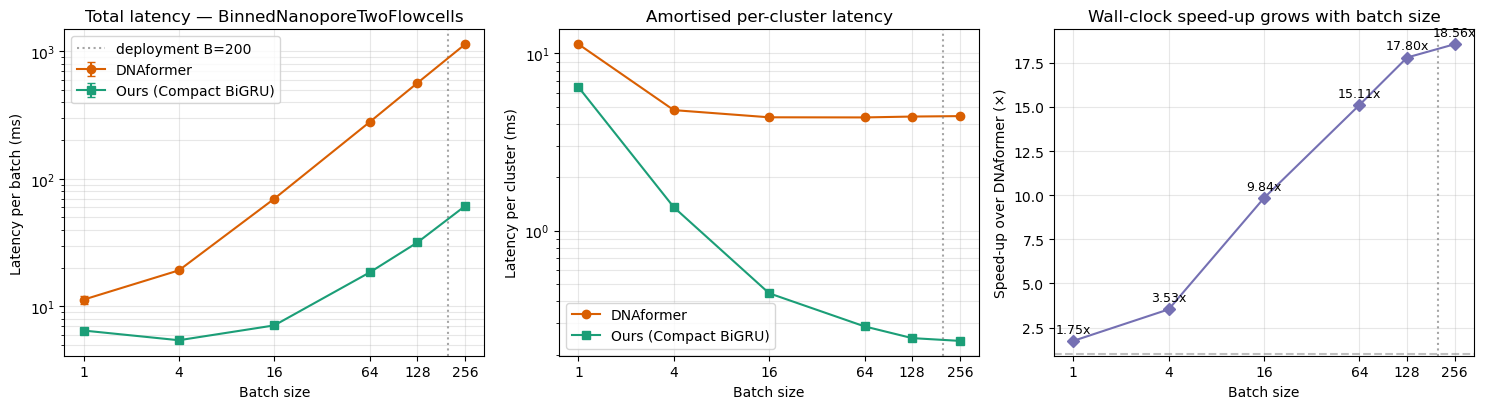

Saved → latency_vs_batch_size.{pdf,png,csv}


In [19]:
# Line plots on log-2 axes — matches the log-2 batch-size sweep.
try:
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    bs = df_sweep["batch_size"].to_numpy()

    # Helper: only plot non-NaN points
    def _plot(ax, x, y, yerr=None, **kw):
        mask = ~np.isnan(y)
        if mask.sum() == 0:
            return
        if yerr is not None:
            ax.errorbar(x[mask], y[mask], yerr=np.asarray(yerr)[mask], capsize=3, **kw)
        else:
            ax.plot(x[mask], y[mask], **kw)

    # 1. Total per-batch latency (log-log)
    ax = axes[0]
    _plot(ax, bs, df_sweep["DNAformer_ms"].to_numpy(),
          yerr=df_sweep["DNAformer_ms_std"].to_numpy(),
          marker="o", label="DNAformer", color="#d95f02")
    _plot(ax, bs, df_sweep["Compact_ms"].to_numpy(),
          yerr=df_sweep["Compact_ms_std"].to_numpy(),
          marker="s", label="Ours (Compact BiGRU)", color="#1b9e77")
    ax.axvline(200, ls=":", color="grey", alpha=0.7, label="deployment B=200")
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(bs); ax.set_xticklabels([str(b) for b in bs])
    ax.set_xlabel("Batch size"); ax.set_ylabel("Latency per batch (ms)")
    ax.set_title(f"Total latency — {SWEEP_DATASET}")
    ax.legend(); ax.grid(True, which="both", alpha=0.3)

    # 2. Per-cluster latency (log-log) — the per-unit-of-work view
    ax = axes[1]
    _plot(ax, bs, df_sweep["DNAformer_ms_per_cluster"].to_numpy(),
          marker="o", label="DNAformer", color="#d95f02")
    _plot(ax, bs, df_sweep["Compact_ms_per_cluster"].to_numpy(),
          marker="s", label="Ours (Compact BiGRU)", color="#1b9e77")
    ax.axvline(200, ls=":", color="grey", alpha=0.7)
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(bs); ax.set_xticklabels([str(b) for b in bs])
    ax.set_xlabel("Batch size"); ax.set_ylabel("Latency per cluster (ms)")
    ax.set_title("Amortised per-cluster latency")
    ax.legend(); ax.grid(True, which="both", alpha=0.3)

    # 3. Speed-up curve (semilog-x)
    ax = axes[2]
    _plot(ax, bs, df_sweep["Speedup_x"].to_numpy(), marker="D", color="#7570b3")
    for b, sp in zip(bs, df_sweep["Speedup_x"]):
        if not math.isnan(sp):
            ax.annotate(f"{sp:.2f}x", (b, sp), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=9)
    ax.axhline(1.0, ls="--", color="grey", alpha=0.5)
    ax.axvline(200, ls=":", color="grey", alpha=0.7)
    ax.set_xscale("log", base=2)
    ax.set_xticks(bs); ax.set_xticklabels([str(b) for b in bs])
    ax.set_xlabel("Batch size"); ax.set_ylabel("Speed-up over DNAformer (×)")
    ax.set_title("Wall-clock speed-up grows with batch size")
    ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig("latency_vs_batch_size.pdf", bbox_inches="tight")
    plt.savefig("latency_vs_batch_size.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved → latency_vs_batch_size.{pdf,png,csv}")
except ImportError:
    print("matplotlib not available; CSV saved only.")

## 11. Architectural differences (qualitative)

| Aspect | DNAformer | Compact BiGRU (ours) |
|---|---|---|
| Sequence model | 12-layer Transformer encoder | 2-layer bidirectional GRU |
| Attention heads | 32 | — |
| Model dimension | `d_model = 1024` | `embedding_filters = 500` |
| Feed-forward dim | `dim_feedforward = 2048` | — |
| Multi-kernel conv | kernels {1, 3, 5, 7}; 4 branches × `double_conv1D` + `linear_block` | kernels {1, 3, 5}; 2 stacked `MultiKernelConvBlock`s |
| Embedding module | 4 branches × `double_conv1D` + `linear_block` | 1 `MultiKernelConvBlock` + linear |
| Siamese (left + flipped) | yes | no |
| Fusion module | yes (2 learnable vectors + 3 × Conv1×1) | no |
| Output head | 3 × Conv1×1 | single linear layer |
| Input encoding | one-hot, 4 channels | learnable `nn.Embedding`, 300-dim |
| Self-attention complexity | O(L²) | O(L) along sequence |
| Parameter count | ~100 M | ~5–8 M |

**Why the compact model has lower FLOPs and parameters.** The 12-layer Transformer encoder is by far
DNAformer's largest cost — removing it eliminates roughly 85 M parameters and the bulk of the FLOPs.
The siamese architecture additionally doubles the per-read pipeline (alignment + embedding +
encoder + output), which our model avoids by using a single branch. The 4-kernel multi-head
convolution and `linear_block` modules are simplified to 3 kernels and a single linear layer.

**On the relationship between FLOPs and wall-clock latency.** The single-cluster timing in §7
(`batch_size = 1`) is dominated by CUDA kernel-launch overhead, not raw FLOPs — every `Conv1d`,
`LayerNorm`, GELU, and per-timestep GRU step issues a separate kernel, and recurrent layers
cannot parallelise along the sequence dimension. The deployment-batch sweep in §10 (`batch_size`
∈ {100, 200, 300}) is the operating point used for both training and DNN inference in our
reference pipeline; at these batch sizes the GPU is saturated and the ~50× FLOP gap translates
into a substantially larger wall-clock advantage. We recommend reporting the §10 numbers as the
primary latency comparison and treating §7 as a per-cluster reference.